In [31]:
from dotenv import load_dotenv
import requests
from agents import Agent, Runner, trace, function_tool, ModelSettings,OpenAIChatCompletionsModel, output_guardrail, GuardrailFunctionOutput
import os
from agents.extensions.visualization import draw_graph
from openai.types.responses import ResponseTextDeltaEvent
import os
import asyncio
import smtplib
from email.message import EmailMessage

from pydantic import BaseModel, Field


In [32]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/nareshchaurasia/nc/PYTHON-ARCHITECT/Python-Immersive-AI-MAC/.env_rag")

api_key = os.getenv("CO_API_KEY")
print(api_key)

cohere_TdqUeFRaqtfoO0Xq86sntO3dMBZ12T3hnQYJ84rT2SYr1u


In [33]:
#load_dotenv(override=True)
MODEL_NAME = "gpt-5.4-mini"

In [34]:
# This __replaces__ the default OpenAI-backend processor with LangSmith's, so traces get sent to your LangSmith project instead of `platform.openai.com/traces`.

from langsmith.wrappers import OpenAIAgentsTracingProcessor
from agents import set_trace_processors

set_trace_processors([OpenAIAgentsTracingProcessor()])

In [5]:
from langsmith import Client
client = Client()
print(client.list_projects(limit=1))  # should not raise 401 if key is valid

<generator object Client.list_projects at 0x1122f93f0>


In [6]:
def send_email(message):
    print("send mail::"+message)

In [7]:
def send_message(message):
    send_email(message)


In [8]:
send_message("Big news")

send mail::Big news


In [9]:
intro = """
You are a sales agent working for ComplAI, 
a company that provides a SaaS tool for ensuring SOC2 compliance and preparing for audits, powered by AI.
You write emails.
"""

instructions1 = intro + "Your email style is professional, serious, with gravitas and credibility."
instructions2 = intro + "Your email style is witty, engaging, and humorous."
instructions3 = intro + "Your email style is concise, to the point, in the style of a busy senior executive."

In [10]:
sales_agent1 = Agent(name="Professional Sales Agent", instructions=instructions1, model=MODEL_NAME)
sales_agent2 = Agent(name="Humorous Sales Agent", instructions=instructions2, model=MODEL_NAME)
sales_agent3 = Agent(name="Executive Sales Agent", instructions=instructions3, model=MODEL_NAME)


In [12]:
@function_tool
def send_email_tool(message: str) -> str:
    """
    Send out an email with the given message
    """
    send_message(message)
    return "Email sent successfully"

### This has automatically been converted into a tool, with the boilerplate json created

In [13]:
send_email_tool.params_json_schema

{'properties': {'message': {'title': 'Message', 'type': 'string'}},
 'required': ['message'],
 'title': 'send_email_tool_args',
 'type': 'object',
 'additionalProperties': False}

In [14]:
decision = """
You pick the best cold sales email from the given options.
Imagine you are a customer and pick the one you are most likely to respond to.
Then use your tool to send the email.
"""

require_tool = ModelSettings(tool_choice="required")

sales_sender = Agent(name="Sales Sender", instructions=decision, model=MODEL_NAME, tools=[send_email_tool], model_settings=require_tool)

Here's the difference between **handoff** and **non-handoff (tools-based)** orchestration in this notebook:

## Non-Handoff (Tools-based) — Section 3a: via Tools

**Flow:** `Sales Manager → Sales Writer Agents → Sales Manager → send_email_tool`

- The **Sales Manager** agent has 4 tools: `tool1`, `tool2`, `tool3` (each wrapping a sales writer agent via `.as_tool()`) and `send_email_tool`.
- The Sales Manager **calls each writer tool** to generate 3 email drafts, gets the results back, evaluates them itself, then **calls `send_email_tool`** to send the best one.
- **Control always returns** to the calling agent (Sales Manager) after each tool call.
- Pattern: **A → B → A** (the orchestrator agent delegates to sub-agents as tools, gets results back, and continues).

## Handoff-based — Section 3b: via Handoffs

**Flow:** `Sales Manager → Sales Writer Agents → Sales Sender (handoff)`

- The **Sales Manager** has 3 tools (`tool1`, `tool2`, `tool3`) to generate drafts, but **no `send_email_tool`**.
- Instead, it has a **handoff** to `sales_sender` agent.
- After generating all 3 drafts, the Sales Manager **hands off control** to the `sales_sender` agent, which then decides which email is best and sends it.
- **Control does NOT return** to the Sales Manager — the `sales_sender` agent takes over completely.
- Pattern: **A → B** (control passes across, not back).

## Key Differences Summarized

| Aspect | Tools (Non-Handoff) | Handoffs |
|--------|-------------------|----------|
| **Control flow** | A → B → A (returns) | A → B (transfers) |
| **Who evaluates & sends?** | The orchestrator (Sales Manager) | The delegated agent (Sales Sender) |
| **Implementation** | Sub-agents wrapped as `.as_tool()` | Agents listed in `handoffs=[...]` parameter |
| **Reliability** | More predictable (author's preference) | Author notes: "not a fan, seems unreliable" |
| **Use case** | Planning agent pattern where orchestrator needs final say | Delegation pattern where sub-agent takes full responsibility |

The author (Ed Donner) explicitly states in the markdown: *"I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks. Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway."*

So the fundamental difference is: **tools return control to the caller** (enabling a hub-and-spoke pattern), while **handoffs transfer control permanently** to the receiving agent (enabling a chain/pipe pattern).

## Part 3: Orchestrating by LLMs

### 3a: via Tools

The simplest way to have 1 Agent choose to invoke another is by treating it as a tool call.

The OpenAI Agents SDK gives a very simple way to do this.

This works best when the flow is:

Agent A -> Agent B -> Agent A

And for the classic "Planning Agent" situation.

### So now we can gather all the tools together:

A tool for each of our 3 email-writing agents

And a tool for our function to send emails

In [17]:
description = "Use this tool to write a sales email. In the input, just instruct it to write a sales email."

tool1 = sales_agent1.as_tool(tool_name="sales_email_writer_1", tool_description=description)
tool2 = sales_agent2.as_tool(tool_name="sales_email_writer_2", tool_description=description)
tool3 = sales_agent3.as_tool(tool_name="sales_email_writer_3", tool_description=description)

tools = [tool1, tool2, tool3, send_email_tool]

tools

[FunctionTool(name='sales_email_writer_1', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'type': 'string'}}, 'required': ['input'], 'title': 'AgentAsToolInput', 'type': 'object', 'additionalProperties': False}, on_invoke_tool=<agents.tool._FailureHandlingFunctionToolInvoker object at 0x112387fe0>, strict_json_schema=True, is_enabled=True, tool_input_guardrails=None, tool_output_guardrails=None, needs_approval=False, timeout_seconds=None, timeout_behavior='error_as_result', timeout_error_function=None, defer_loading=False),
 FunctionTool(name='sales_email_writer_2', description='Use this tool to write a sales email. In the input, just instruct it to write a sales email.', params_json_schema={'description': 'Default input schema for agent-as-tool calls.', 'properties': {'input': {'title': 'Input', 'typ

## And now it's time for our Sales Manager - our planning agent

In [18]:
instructions = """
You are a Sales Manager at ComplAI. Your goal is to find the single best cold sales email using the sales_writer tools.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Evaluate and Select: Review the drafts and choose the single best email using your judgment of which one is most effective.
 
3. Use your tool to send the best email (and only the best email) to the user. Only send 1 email.
"""


In [19]:
sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, model=MODEL_NAME)

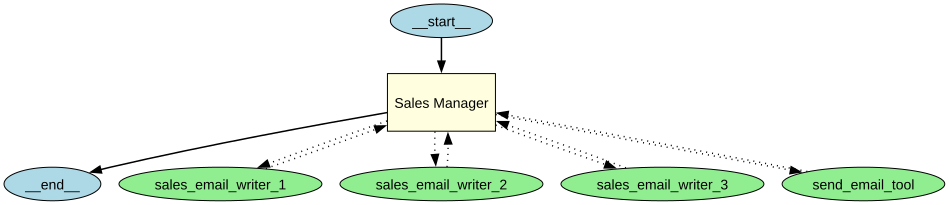

In [20]:
draw_graph(sales_manager)

In [21]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

send mail::Subject: SOC 2, but make it less “audit panic,” more “we’ve got this”

Hi [First Name],

Hope your week is going well and your compliance stress level is somewhere below “all hands emergency.”

If SOC 2 has been living rent-free in your head, ComplAI can help.

We built an AI-powered SaaS tool that helps companies stay on top of SOC 2 compliance and get audit-ready without turning your team into part-time spreadsheet archaeologists. Think less “where is that evidence?” and more “already handled.”

With ComplAI, you can:
- Keep compliance tasks organized and moving
- Prep for audits with a lot less chaos
- Save time by automating the tedious stuff
- Make your security/compliance process feel weirdly manageable

If it’s helpful, I’d love to show you how teams use ComplAI to make SOC 2 feel less like a fire drill and more like a process.

Would you be open to a quick 15-minute chat next week?

Best,  
[Your Name]  
ComplAI


## Remember to check the trace

https://platform.openai.com/traces

And then check your email!! Also look in your Junk / Spam folder - after all, this is basically a spam message..


## Part 3: Orchestrating by LLMs

### 3a: via Handoffs

I am not a fan of handoffs. They seem very unreliable. They're not used consistently by other frameworks.

Behind the scenes, OpenAI Agents SDK has implemented these with Tools anyway.

### Handoffs represent a way an agent can delegate to an agent, passing control to it

Handoffs and Agents-as-tools are similar:

In both cases, an Agent can collaborate with another Agent

With tools, control passes back

A -> B -> A

With handoffs, control passes across

A -> B

In [ ]:

instructions = """
You are a Sales Manager at ComplAI. You get your sales team to draft emails, then send them all to a sales picker.
"""

task = """
Follow these steps:

1. Generate Drafts: Use each of the three sales_email_writer tools to generate different email drafts.
Just instruct each to write a sales email; no further details are needed.
Do not proceed until all three drafts are ready, one from each tool.
 
2. Handoff to the sales sender to choose and send the best email.
"""

tools = [tool1, tool2, tool3]
handoffs = [sales_sender]

sales_manager = Agent(name="Sales Manager", instructions=instructions, tools=tools, handoffs=handoffs, model=MODEL_NAME)


In [ ]:
draw_graph(sales_manager)

In [ ]:
with trace("Sales manager"):
    result = await Runner.run(sales_manager, task)

## Part 2: Structured Outputs

An LLM produces text in natural language. But we can have it instead produce a "python object".

This is accomplished as follows:

1. We specify a Python object  
2. In the System prompt, the LLM is instructed to respond in JSON and follow a Schema which represents the Python object  
3. The LLM outputs JSON, and the framework populates a Python object based on it

When we specify the Python object, we create a subclass of BaseModel, which is part of the Pydantic framework.

Pydantic is a framework that easily allows defining a JSON schema and mapping between Python and json.



In [24]:
class EmailReview(BaseModel):
    is_professional: bool = Field(description="Whether the email is professional and appropriate")
    number_of_sentences: int = Field(description="The number of sentences in the body of the email, not including the greeting and signature")
    contains_placeholders: bool = Field(description="Whether the email contains placeholders for personalization")

In [25]:
EmailReview.model_json_schema()

{'properties': {'is_professional': {'description': 'Whether the email is professional and appropriate',
   'title': 'Is Professional',
   'type': 'boolean'},
  'number_of_sentences': {'description': 'The number of sentences in the body of the email, not including the greeting and signature',
   'title': 'Number Of Sentences',
   'type': 'integer'},
  'contains_placeholders': {'description': 'Whether the email contains placeholders for personalization',
   'title': 'Contains Placeholders',
   'type': 'boolean'}},
 'required': ['is_professional',
  'number_of_sentences',
  'contains_placeholders'],
 'title': 'EmailReview',
 'type': 'object'}

In [ ]:
email_prompt = """
Hi [first_name],

I'm hitting you up to see if you'd like to buy our product. It's really great. You'll miss out if you don't buy it.

Laters.

Ed
"""

In [ ]:
checker = Agent(name="Checker", instructions="You review potential sales emails", model="gpt-5.4-mini", output_type=EmailReview)
result = await Runner.run(checker, email_prompt)

In [28]:
review = result.final_output
review

EmailReview(is_professional=False, number_of_sentences=3, contains_placeholders=True)

In [29]:
review.is_professional

False

### Guardrails

* https://openai.github.io/openai-agents-python/guardrails/

Guardrails enable you to do checks and validations of user input and agent output. For example, imagine you have an agent that uses a very smart (and hence slow/expensive) model to help with customer requests. You wouldn't want malicious users to ask the model to help them with their math homework. So, you can run a guardrail with a fast/cheap model. If the guardrail detects malicious usage, it can immediately raise an error and prevent the expensive model from running, saving you time and money (when using blocking guardrails; for parallel guardrails, the expensive model may have already started running before the guardrail completes. See "Execution modes" below for details).

There are two kinds of guardrails:

* Input guardrails run on the initial user input
* Output guardrails run on the final agent output

**Workflow boundaries**
Guardrails are attached to agents and tools, but they do not all run at the same points in a workflow:

* Input guardrails run only for the first agent in the chain.
* Output guardrails run only for the agent that produces the final output.
* Tool guardrails run on every custom function-tool invocation, with input guardrails before execution and output guardrails after execution.

In [ ]:
# @output_guardrail
# async def email_guardrail(ctx, agent, message):
#     result = await Runner.run(checker, message, context=ctx.context)
#     review = result.final_output
#     is_problem = review.contains_placeholders or not review.is_professional
#     return GuardrailFunctionOutput(output_info={"review": review},tripwire_triggered=is_problem)

In [ ]:
# cowboy_instructions = instructions + "\nSpeak like a cowboy"

# sales_agent_cowboy = Agent(name="Cowboy", instructions=cowboy_instructions, model=MODEL_NAME, output_guardrails=[email_guardrail])

In [ ]:
# result = await Runner.run(sales_agent_cowboy, "Write a cold sales email")
# result.final_output